# 02. Sign Event Policy Candidate

이 노트북의 목적은 **YOLO 표지판 detection을 주행 상태머신으로 넘길 1회성 event로 변환하는 정책**을 만드는 것이다.

01 노트북에서 정한 것은 detection gate였다.

```text
bbox가 오른쪽 절반에 있는가?
confidence가 충분한가?
bbox 면적이 충분히 큰가?
```

02 노트북에서는 그 다음을 다룬다.

```text
sign 후보 detection
→ class별 주행 의미를 반영한 trigger 조건 적용
→ 1회성 sign event 후보 생성
→ state machine이 사용할 candidate config 저장
```

여기서 만드는 값은 최종 고정값이 아니라, Pi 실습에서 바로 수정 가능한 **초기 candidate**다.


## 0. 파라미터 역할 정리

02에서 다루는 값들은 두 그룹으로 나뉜다.

### Detection gate 계열

| 값 | 의미 |
|---|---|
| `min_conf` | YOLO가 해당 class라고 믿는 정도의 최소값 |
| `min_area_ratio` | bbox가 전체 이미지에서 차지하는 최소 면적 비율. 가까움/크기의 대리값 |
| `roi` | bbox 중심이 들어와야 하는 위치 영역 |

### Event trigger / state metadata 계열

| 값 | 의미 |
|---|---|
| `vote_window` | 최근 몇 프레임을 볼지 |
| `required_hits` | 그 window 안에서 몇 번 이상 감지되어야 event로 인정할지 |
| `cooldown_sec` | 같은 event가 중복 발생하지 않도록 막는 시간 |
| `hold_sec` | event 발생 후 state machine에서 효과를 유지할 시간 |
| `priority` | 동시에 여러 event 후보가 생겼을 때 선택 우선순위 |

중요한 점: `hold_sec`은 event trigger가 직접 자동차를 제어하는 시간이 아니다.  
event에 붙는 metadata이고, 실제 해석은 `state_machine.py`에서 한다.


## 1. 경로와 01 결과 불러오기

이 노트북은 01의 raw detection 결과를 재사용한다.

필요 파일:

- `raw_detections_low_conf.csv`
- `image_event_summary_by_candidate.csv`
- `candidate_summary.csv`

01을 먼저 실행해야 한다.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import math

import cv2
import numpy as np
import pandas as pd
from IPython.display import display, Image as IPyImage

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
EXP_ROOT = PROJECT_ROOT / "10_experiments" / "20_sign_event_contract"
INPUT_ROOT = EXP_ROOT / "review_outputs" / "01_sign_event_gate_overlay_probe"
INPUT_TABLE_DIR = INPUT_ROOT / "tables"

OUT_ROOT = EXP_ROOT / "review_outputs" / "02_sign_event_policy_candidate"
TABLE_DIR = OUT_ROOT / "tables"
OVERLAY_DIR = OUT_ROOT / "overlays"
for p in [OUT_ROOT, TABLE_DIR, OVERLAY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["horn", "left", "right", "speed_20", "stop", "straight"]
BASE_CANDIDATE_FROM_01 = "balanced_right_half"

raw_path = INPUT_TABLE_DIR / "raw_detections_low_conf.csv"
image_summary_path = INPUT_TABLE_DIR / "image_event_summary_by_candidate.csv"
candidate_summary_path = INPUT_TABLE_DIR / "candidate_summary.csv"
for p in [raw_path, image_summary_path, candidate_summary_path]:
    assert p.exists(), f"Missing 01 output: {p}"

raw_df = pd.read_csv(raw_path, encoding="utf-8-sig")
image_summary_all = pd.read_csv(image_summary_path, encoding="utf-8-sig")
candidate_summary = pd.read_csv(candidate_summary_path, encoding="utf-8-sig")

# 01의 balanced 후보를 image manifest로 사용한다. 후보별로 같은 이미지가 반복되어 있으므로 하나만 고른다.
image_manifest = image_summary_all[image_summary_all["candidate"] == BASE_CANDIDATE_FROM_01].copy()
image_manifest = image_manifest[["image_key", "expected_label", "filename", "path"]].drop_duplicates("image_key")

print("raw detections:", len(raw_df))
print("images:", len(image_manifest))
print("output:", OUT_ROOT)
display(candidate_summary)


raw detections: 494
images: 480
output: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate


,candidate,images,event_rate,correct_event_rate,wrong_event_rate,no_event_rate,mean_event_confidence,mean_event_area_ratio
0,balanced_right_half,480,0.843750,0.841667,0.002083,0.156250,0.767591,0.012558
1,loose_right_half,480,0.916667,0.912500,0.004167,0.083333,0.756290,0.011913
2,strict_right_event,480,0.593750,0.591667,0.002083,0.406250,0.800098,0.014703


## 2. 01 Detection Gate 기준

01 결과에서 가장 현실적인 출발점은 `balanced_right_half`였다.

```text
ROI: 오른쪽 절반
min_conf: 0.45
min_area_ratio: 0.003
```

다만 02에서는 class별 주행 의미가 다르기 때문에 `area_ratio`, `conf`, `hold_sec`, `cooldown`을 class별로 다르게 둔다.


In [2]:
DETECTION_GATE_REFERENCE = {
    "source_notebook": "01_sign_event_gate_overlay_probe",
    "base_candidate": BASE_CANDIDATE_FROM_01,
    "global_roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
    "global_min_conf": 0.45,
    "global_min_area_ratio": 0.003,
    "meaning": "right-half sign candidate gate from 01; class policies below may override min_conf/min_area_ratio.",
}

pd.DataFrame([DETECTION_GATE_REFERENCE]).to_csv(TABLE_DIR / "detection_gate_reference.csv", index=False, encoding="utf-8-sig")
display(pd.DataFrame([DETECTION_GATE_REFERENCE]))


,source_notebook,base_candidate,global_roi,global_min_conf,global_min_area_ratio,meaning
0,01_sign_event_gate_overlay_probe,balanced_right_half,"{'x_min': 0.5, 'x_max': 1.0, 'y_min': 0.0, 'y_...",0.45,0.003,right-half sign candidate gate from 01; class ...


## 3. Class별 Event 의미와 초기 정책

이 표는 실제 시연 상황을 상상한 사전 지식을 반영한 초안이다.

- `speed_20`: 멀리서 보여도 감속을 미리 시작하는 게 좋다.
- `straight`: 가까이 오기 전부터 직진 구간임을 알려주는 예고 신호로 쓴다.
- `left/right`: 너무 멀리서 발생하면 안 되고, 교차로 직전에 가까워졌을 때 발생해야 한다.
- `stop`: 멀리서 정지하면 안 되므로 가장 보수적으로 둔다.
- `horn`: 주행 방향에는 직접 영향이 작으므로 중간 정도 거리에서 1회 event로 둔다.

이 값들은 최종값이 아니라 Pi debug에서 바로 수정할 수 있는 초기값이다.


In [3]:
SIGN_EVENT_POLICY = {
    "speed_20": {
        "event_name": "sign_speed_20",
        "min_conf": 0.45,
        "min_area_ratio": 0.002,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 1,
        "cooldown_sec": 5.0,
        "hold_sec": 5.0,
        "priority": 50,
        "state_machine_hint": "enter slow driving mode early",
    },
    "straight": {
        "event_name": "sign_straight",
        "min_conf": 0.45,
        "min_area_ratio": 0.003,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 2,
        "cooldown_sec": 3.0,
        "hold_sec": 3.0,
        "priority": 60,
        "state_machine_hint": "temporarily bias driving state toward straight",
    },
    "left": {
        "event_name": "sign_left",
        "min_conf": 0.45,
        "min_area_ratio": 0.006,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 2,
        "cooldown_sec": 4.0,
        "hold_sec": 2.5,
        "priority": 70,
        "state_machine_hint": "prepare or execute left turn near intersection",
    },
    "right": {
        "event_name": "sign_right",
        "min_conf": 0.45,
        "min_area_ratio": 0.006,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 2,
        "cooldown_sec": 4.0,
        "hold_sec": 2.5,
        "priority": 70,
        "state_machine_hint": "prepare or execute right turn near intersection",
    },
    "horn": {
        "event_name": "sign_horn",
        "min_conf": 0.40,
        "min_area_ratio": 0.004,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 2,
        "cooldown_sec": 5.0,
        "hold_sec": 0.5,
        "priority": 40,
        "state_machine_hint": "trigger horn action once",
    },
    "stop": {
        "event_name": "sign_stop",
        "min_conf": 0.50,
        "min_area_ratio": 0.008,
        "roi": {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00},
        "vote_window": 5,
        "required_hits": 2,
        "cooldown_sec": 6.0,
        "hold_sec": 2.0,
        "priority": 90,
        "state_machine_hint": "stop only when sign is close enough",
    },
}

policy_df = pd.DataFrame([
    {"class": cls, **params, "roi": json.dumps(params["roi"], ensure_ascii=False)}
    for cls, params in SIGN_EVENT_POLICY.items()
])
policy_df.to_csv(TABLE_DIR / "class_trigger_params.csv", index=False, encoding="utf-8-sig")
display(policy_df[["class", "event_name", "min_conf", "min_area_ratio", "vote_window", "required_hits", "cooldown_sec", "hold_sec", "priority", "state_machine_hint"]])


,class,event_name,min_conf,min_area_ratio,vote_window,required_hits,cooldown_sec,hold_sec,priority,state_machine_hint
0,speed_20,sign_speed_20,0.45,0.002,5,1,5.0,5.0,50,enter slow driving mode early
1,straight,sign_straight,0.45,0.003,5,2,3.0,3.0,60,temporarily bias driving state toward straight
2,left,sign_left,0.45,0.006,5,2,4.0,2.5,70,prepare or execute left turn near intersection
3,right,sign_right,0.45,0.006,5,2,4.0,2.5,70,prepare or execute right turn near intersection
4,horn,sign_horn,0.40,0.004,5,2,5.0,0.5,40,trigger horn action once
5,stop,sign_stop,0.50,0.008,5,2,6.0,2.0,90,stop only when sign is close enough


## 4. 단일 이미지 기준 Event 후보 계산

현재 데이터는 독립 이미지 샘플이다. 따라서 진짜 temporal voting은 평가할 수 없다.

여기서는 각 이미지에서 다음만 확인한다.

```text
이 이미지가 한 프레임이라고 가정했을 때,
class별 trigger 조건을 만족하는 detection이 있는가?
있다면 어떤 event가 후보가 되는가?
```

실제 런타임에서는 이 결과가 프레임마다 들어오고, `vote_window / required_hits / cooldown_sec`이 시간 축에서 적용된다.


In [4]:
def in_roi(row, roi):
    return (
        float(roi["x_min"]) <= float(row["cx_norm"]) <= float(roi["x_max"])
        and float(roi["y_min"]) <= float(row["cy_norm"]) <= float(roi["y_max"])
    )

def row_passes_policy(row, policy):
    label = row["pred_label"]
    if label not in policy:
        return False
    p = policy[label]
    return (
        float(row["confidence"]) >= float(p["min_conf"])
        and float(row["area_ratio"]) >= float(p["min_area_ratio"])
        and in_roi(row, p["roi"])
    )

def failure_reasons_for_expected(det_rows, expected_label, policy):
    expected = det_rows[det_rows["pred_label"] == expected_label]
    if len(expected) == 0:
        return ["no_expected_detection_at_low_conf"]
    p = policy[expected_label]
    # confidence가 가장 높은 expected detection을 기준으로 탈락 이유를 본다.
    best = expected.sort_values("confidence", ascending=False).iloc[0]
    reasons = []
    if float(best["confidence"]) < float(p["min_conf"]):
        reasons.append("conf")
    if float(best["area_ratio"]) < float(p["min_area_ratio"]):
        reasons.append("area")
    if not in_roi(best, p["roi"]):
        reasons.append("roi")
    if not reasons:
        reasons.append("expected_passed_but_not_selected")
    return reasons

def choose_event_candidate(det_rows, policy):
    passed = []
    for _, row in det_rows.iterrows():
        if row_passes_policy(row, policy):
            p = policy[row["pred_label"]]
            item = row.to_dict()
            item.update({
                "event_name": p["event_name"],
                "priority": p["priority"],
                "hold_sec": p["hold_sec"],
                "cooldown_sec": p["cooldown_sec"],
            })
            passed.append(item)
    if not passed:
        return None, []
    passed_df = pd.DataFrame(passed)
    # 우선순위가 높은 event를 먼저 고르고, 같은 우선순위에서는 가까운 표지판(area), confidence 순서로 고른다.
    passed_df = passed_df.sort_values(["priority", "area_ratio", "confidence"], ascending=[False, False, False])
    return passed_df.iloc[0].to_dict(), passed_df.to_dict("records")

single_frame_rows = []
passed_candidate_rows = []
for _, img in image_manifest.iterrows():
    key = img["image_key"]
    expected = img["expected_label"]
    det = raw_df[raw_df["image_key"] == key].copy()
    chosen, passed = choose_event_candidate(det, SIGN_EVENT_POLICY)
    passed_candidate_rows.extend([{**r, "image_key": key, "expected_label": expected, "filename": img["filename"], "path": img["path"]} for r in passed])
    if chosen is None:
        reasons = failure_reasons_for_expected(det, expected, SIGN_EVENT_POLICY)
        single_frame_rows.append({
            "image_key": key,
            "expected_label": expected,
            "filename": img["filename"],
            "path": img["path"],
            "event_label": "none",
            "event_name": "none",
            "event_confidence": np.nan,
            "event_area_ratio": np.nan,
            "event_cx_norm": np.nan,
            "event_cy_norm": np.nan,
            "priority": np.nan,
            "hold_sec": np.nan,
            "cooldown_sec": np.nan,
            "correct_event": False,
            "wrong_event": False,
            "no_event": True,
            "expected_failure_reasons": ";".join(reasons),
        })
    else:
        single_frame_rows.append({
            "image_key": key,
            "expected_label": expected,
            "filename": img["filename"],
            "path": img["path"],
            "event_label": chosen["pred_label"],
            "event_name": chosen["event_name"],
            "event_confidence": float(chosen["confidence"]),
            "event_area_ratio": float(chosen["area_ratio"]),
            "event_cx_norm": float(chosen["cx_norm"]),
            "event_cy_norm": float(chosen["cy_norm"]),
            "priority": int(chosen["priority"]),
            "hold_sec": float(chosen["hold_sec"]),
            "cooldown_sec": float(chosen["cooldown_sec"]),
            "correct_event": bool(chosen["pred_label"] == expected),
            "wrong_event": bool(chosen["pred_label"] != expected),
            "no_event": False,
            "expected_failure_reasons": "",
        })

single_frame_df = pd.DataFrame(single_frame_rows)
passed_candidates_df = pd.DataFrame(passed_candidate_rows)
single_frame_df.to_csv(TABLE_DIR / "single_frame_event_candidates.csv", index=False, encoding="utf-8-sig")
passed_candidates_df.to_csv(TABLE_DIR / "passed_detection_candidates.csv", index=False, encoding="utf-8-sig")

summary = single_frame_df.groupby("expected_label").agg(
    images=("image_key", "count"),
    event_rate=("no_event", lambda s: float((~s).mean())),
    correct_event_rate=("correct_event", "mean"),
    wrong_event_rate=("wrong_event", "mean"),
    no_event_rate=("no_event", "mean"),
    mean_event_confidence=("event_confidence", "mean"),
    mean_event_area_ratio=("event_area_ratio", "mean"),
).reset_index()
summary.to_csv(TABLE_DIR / "single_frame_event_summary_by_class.csv", index=False, encoding="utf-8-sig")

overall = pd.DataFrame([{
    "images": len(single_frame_df),
    "event_rate": float((~single_frame_df["no_event"]).mean()),
    "correct_event_rate": float(single_frame_df["correct_event"].mean()),
    "wrong_event_rate": float(single_frame_df["wrong_event"].mean()),
    "no_event_rate": float(single_frame_df["no_event"].mean()),
}])
overall.to_csv(TABLE_DIR / "single_frame_event_summary_overall.csv", index=False, encoding="utf-8-sig")

display(overall)
display(summary)


,images,event_rate,correct_event_rate,wrong_event_rate,no_event_rate
0,480,0.6875,0.685417,0.002083,0.3125


,expected_label,images,event_rate,correct_event_rate,wrong_event_rate,no_event_rate,mean_event_confidence,mean_event_area_ratio
0,horn,80,0.4625,0.4625,0.0000,0.5375,0.675284,0.008566
1,left,80,0.6375,0.6250,0.0125,0.3625,0.776076,0.012787
2,right,80,0.7000,0.7000,0.0000,0.3000,0.618116,0.019283
3,speed_20,80,0.8750,0.8750,0.0000,0.1250,0.866022,0.013372
4,stop,80,0.5500,0.5500,0.0000,0.4500,0.841550,0.017503
5,straight,80,0.9000,0.9000,0.0000,0.1000,0.844678,0.013987


## 5. 탈락 이유 확인

event가 발생하지 않은 이미지는 단순히 나쁜 것이 아니다.

예를 들어 멀리 있는 `left/right/stop` 표지판은 event가 안 뜨는 것이 정상일 수 있다.  
하지만 가까운 표지판인데 `area` 때문에 탈락한다면 threshold를 수정해야 한다.

이 셀은 no-event 이미지에서 기대 class가 왜 탈락했는지 요약한다.


In [5]:
fail_rows = []
for _, row in single_frame_df[single_frame_df["no_event"]].iterrows():
    reasons = str(row["expected_failure_reasons"]).split(";") if row["expected_failure_reasons"] else ["unknown"]
    for reason in reasons:
        fail_rows.append({"expected_label": row["expected_label"], "reason": reason})
fail_df = pd.DataFrame(fail_rows)
if len(fail_df):
    fail_summary = fail_df.groupby(["expected_label", "reason"]).size().reset_index(name="count")
else:
    fail_summary = pd.DataFrame(columns=["expected_label", "reason", "count"])
fail_summary.to_csv(TABLE_DIR / "no_event_failure_reason_summary.csv", index=False, encoding="utf-8-sig")
display(fail_summary)

wrong_df = single_frame_df[single_frame_df["wrong_event"]].copy()
wrong_df.to_csv(TABLE_DIR / "wrong_event_cases.csv", index=False, encoding="utf-8-sig")
if len(wrong_df):
    display(wrong_df[["expected_label", "event_label", "event_confidence", "event_area_ratio", "event_cx_norm", "filename"]])
else:
    print("No wrong single-frame event cases.")


,expected_label,reason,count
0,horn,area,36
1,horn,conf,5
2,horn,no_expected_detection_at_low_conf,7
3,left,area,26
4,left,conf,1
5,left,no_expected_detection_at_low_conf,3
6,left,roi,4
7,right,area,21
8,right,conf,1
9,right,no_expected_detection_at_low_conf,2


,expected_label,event_label,event_confidence,event_area_ratio,event_cx_norm,filename
104,left,stop,0.587922,0.020678,0.940199,20260430_174502_signs_left_moving_mixed_right_...


## 6. Overlay 생성

Overlay 색상 의미:

- **초록 bbox**: 선택된 event가 기대 class와 일치
- **주황 bbox**: 선택된 event가 기대 class와 다름
- **파란 bbox**: event 조건은 통과했지만 우선순위/크기에서 밀려 선택되지 않음
- **회색 bbox**: YOLO detection은 되었지만 class별 event 조건에서 탈락

이 overlay는 02의 핵심 검수 자료다.

볼 것:

- `left/right/stop`은 너무 멀리서 event가 뜨지 않는가?
- `speed_20/straight`는 지나치게 늦게 뜨지 않는가?
- `horn`은 너무 약하게 걸러지지 않는가?


In [6]:
def imread_bgr(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def draw_text(img, text, org, scale=0.45, color=(255, 255, 255), bg=(0, 0, 0), thickness=1):
    x, y = org
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    cv2.rectangle(img, (x - 2, y - th - baseline - 2), (x + tw + 2, y + baseline + 2), bg, -1)
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

COLOR_SELECTED_OK = (60, 220, 60)
COLOR_SELECTED_BAD = (0, 165, 255)
COLOR_PASSED_OTHER = (255, 120, 30)
COLOR_REJECT = (160, 160, 160)
COLOR_ROI = (255, 190, 80)


def annotate_event_policy_image(img_row):
    bgr = imread_bgr(img_row["path"])
    h, w = bgr.shape[:2]
    out = bgr.copy()
    key = img_row["image_key"]
    expected = img_row["expected_label"]
    det = raw_df[raw_df["image_key"] == key].copy()
    chosen_row = single_frame_df[single_frame_df["image_key"] == key].iloc[0]
    passed_for_image = passed_candidates_df[passed_candidates_df["image_key"] == key].copy() if len(passed_candidates_df) else pd.DataFrame()

    # 공통 right-half ROI를 배경으로 표시한다.
    roi = DETECTION_GATE_REFERENCE["global_roi"]
    rx1, ry1 = int(roi["x_min"] * w), int(roi["y_min"] * h)
    rx2, ry2 = int(roi["x_max"] * w), int(roi["y_max"] * h)
    overlay = out.copy()
    cv2.rectangle(overlay, (rx1, ry1), (rx2, ry2), COLOR_ROI, -1)
    out = cv2.addWeighted(overlay, 0.10, out, 0.90, 0)
    cv2.rectangle(out, (rx1, ry1), (rx2, ry2), COLOR_ROI, 2)

    chosen_id = None
    if not bool(chosen_row["no_event"]):
        chosen_id = (
            chosen_row["event_label"],
            round(float(chosen_row["event_confidence"]), 4),
            round(float(chosen_row["event_area_ratio"]), 6),
        )

    for _, row in det.iterrows():
        p = SIGN_EVENT_POLICY.get(row["pred_label"])
        passes = row_passes_policy(row, SIGN_EVENT_POLICY)
        this_id = (row["pred_label"], round(float(row["confidence"]), 4), round(float(row["area_ratio"]), 6))
        is_selected = chosen_id is not None and this_id == chosen_id
        if is_selected:
            color = COLOR_SELECTED_OK if row["pred_label"] == expected else COLOR_SELECTED_BAD
            thickness = 4
        elif passes:
            color = COLOR_PASSED_OTHER
            thickness = 2
        else:
            color = COLOR_REJECT
            thickness = 2
        x1, y1, x2, y2 = [int(round(float(row[v]))) for v in ["x1", "y1", "x2", "y2"]]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        txt = f"{row['pred_label']} {row['confidence']:.2f} ar={row['area_ratio']:.3f}"
        draw_text(out, txt, (max(2, x1), max(16, y1 - 3)), scale=0.42, bg=color)

    status = f"GT={expected} | event={chosen_row['event_label']} | ar={chosen_row['event_area_ratio'] if not chosen_row['no_event'] else 'none'}"
    draw_text(out, status, (10, 24), scale=0.56, bg=(30, 30, 30))
    return out

def resize_to_cell(img, cell_w, cell_h):
    h, w = img.shape[:2]
    scale = min(cell_w / w, cell_h / h)
    nw, nh = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((cell_h, cell_w, 3), 245, dtype=np.uint8)
    x0 = (cell_w - nw) // 2
    y0 = (cell_h - nh) // 2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    return canvas

def make_sheet(rows_df, out_path, title, cols=3, cell_w=520, cell_h=390):
    imgs = []
    for _, row in rows_df.iterrows():
        imgs.append(resize_to_cell(annotate_event_policy_image(row), cell_w, cell_h))
    if not imgs:
        return None
    n = len(imgs)
    grid_rows = int(math.ceil(n / cols))
    title_h = 52
    sheet = np.full((title_h + grid_rows * cell_h, cols * cell_w, 3), 250, dtype=np.uint8)
    draw_text(sheet, title, (12, 34), scale=0.78, bg=(50, 50, 50))
    for i, img in enumerate(imgs):
        r, c = divmod(i, cols)
        y, x = title_h + r * cell_h, c * cell_w
        sheet[y:y+cell_h, x:x+cell_w] = img
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), sheet)
    return out_path

print("overlay helpers ready")


overlay helpers ready


## 7. Mixed / Class별 Overlay 생성

mixed overlay는 전체적인 감을 보기 위한 것이고, class별 overlay는 threshold가 각 class에 맞는지 보는 용도다.

class별 sheet는 의도적으로 다음 케이스를 섞는다.

- event 발생한 샘플
- no-event 샘플
- wrong-event 샘플
- area_ratio가 작은 샘플
- area_ratio가 큰 샘플


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\mixed_sign_event_policy_candidate.jpg


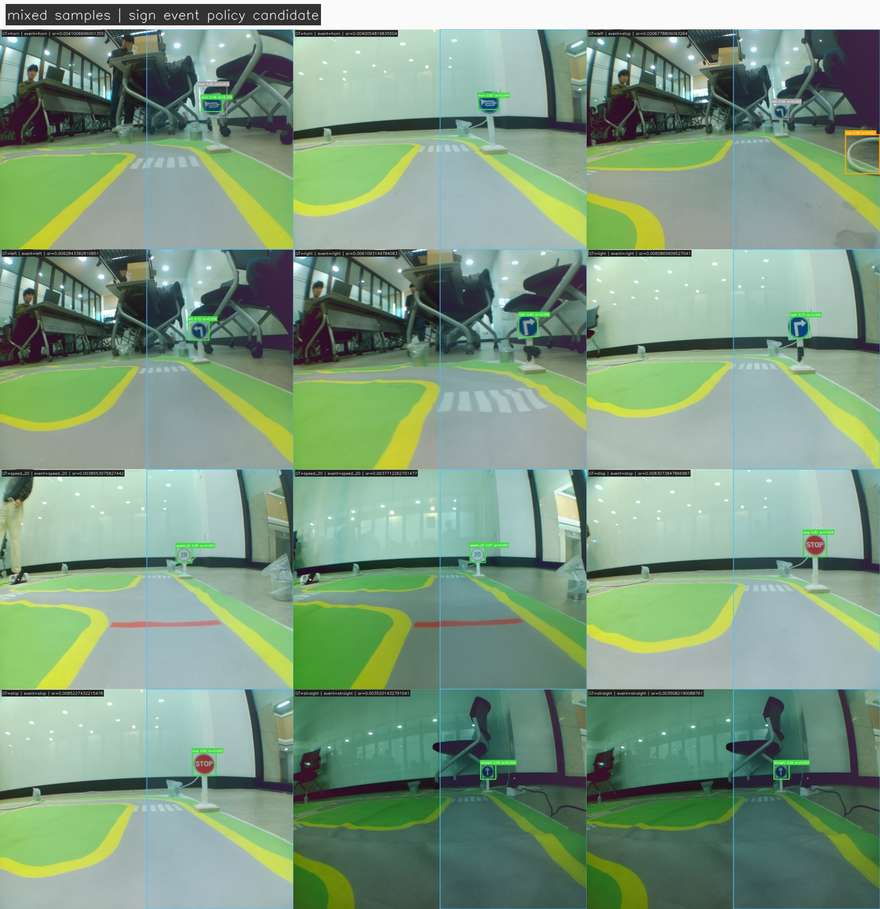

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__horn.jpg


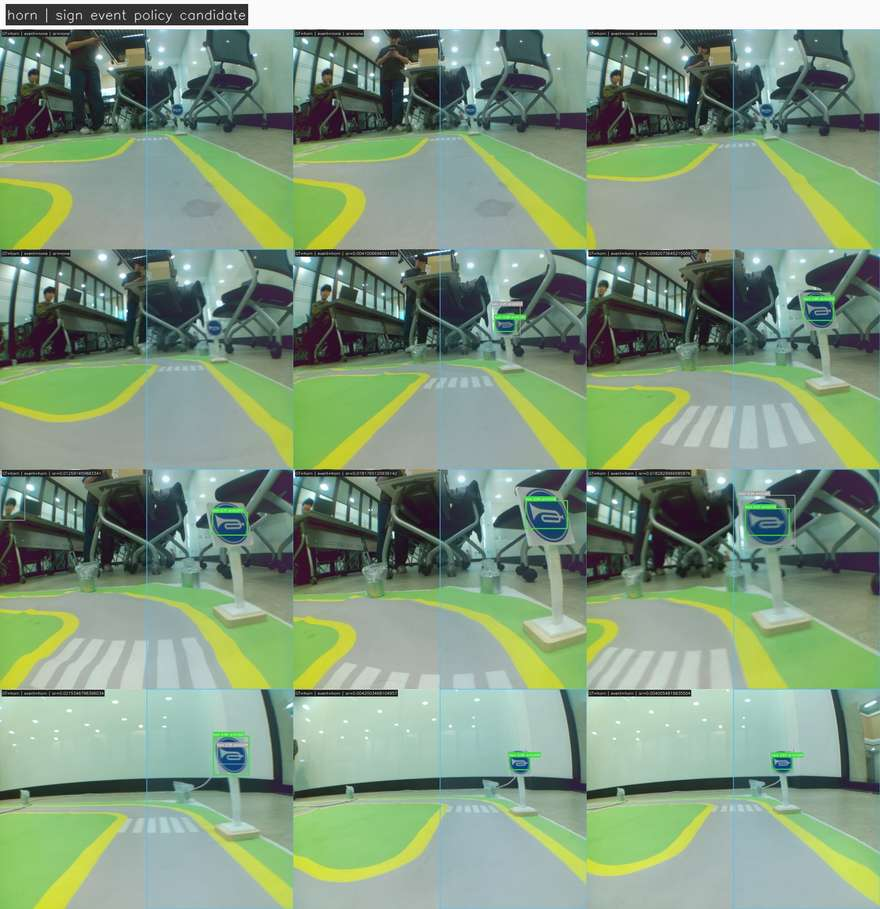

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__left.jpg


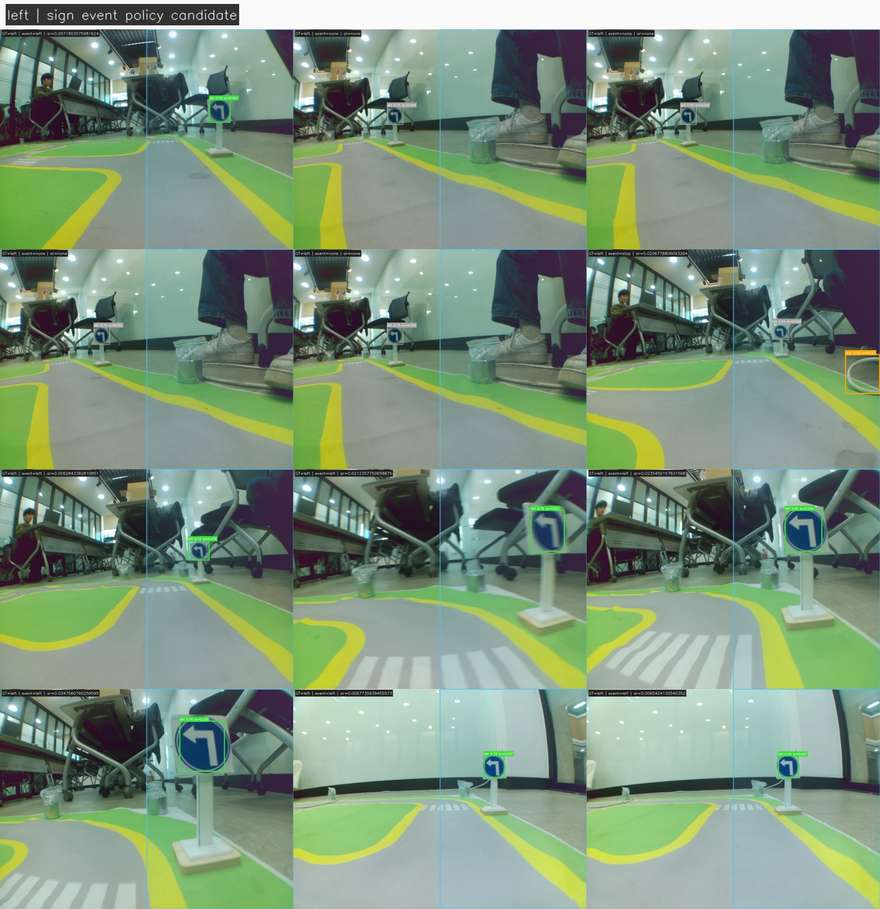

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__right.jpg


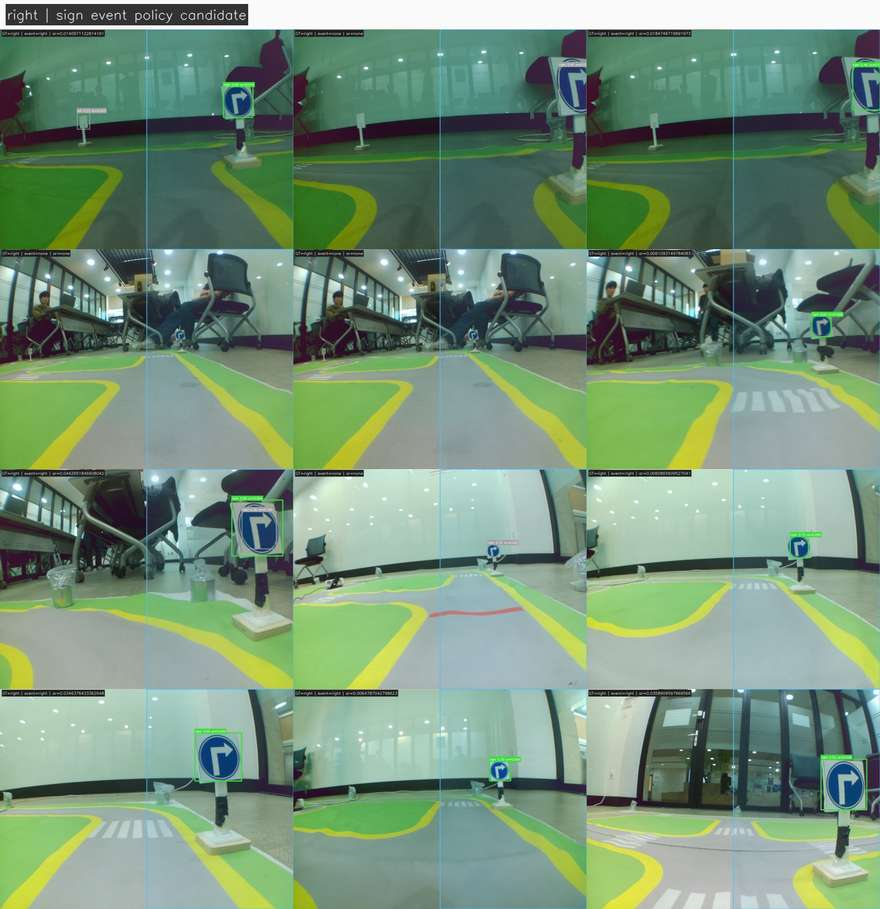

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__speed_20.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__stop.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays\sign_event_policy__straight.jpg


In [7]:
def select_rows_for_label(label, max_n=12):
    sub = single_frame_df[single_frame_df["expected_label"] == label].copy()
    picked_keys = []
    # wrong은 반드시 앞에 둔다.
    wrong = sub[sub["wrong_event"]].sort_values(["event_area_ratio", "event_confidence"], ascending=[False, False])
    picked_keys.extend(wrong["image_key"].head(3).tolist())
    # event 발생: 작은 area와 큰 area를 같이 본다.
    ev = sub[~sub["no_event"]].copy()
    if len(ev):
        picked_keys.extend(ev.sort_values("event_area_ratio", ascending=True)["image_key"].head(3).tolist())
        picked_keys.extend(ev.sort_values("event_area_ratio", ascending=False)["image_key"].head(3).tolist())
    # no-event도 본다.
    no = sub[sub["no_event"]]
    if len(no):
        picked_keys.extend(no["image_key"].head(4).tolist())
    # 부족하면 균등 샘플
    all_keys = sub["image_key"].tolist()
    if len(all_keys):
        idx = np.linspace(0, len(all_keys) - 1, min(max_n, len(all_keys))).round().astype(int)
        picked_keys.extend([all_keys[i] for i in idx])
    seen = set()
    unique = []
    for k in picked_keys:
        if k not in seen:
            seen.add(k)
            unique.append(k)
    unique = unique[:max_n]
    return sub[sub["image_key"].isin(unique)]

def rows_by_keys(keys):
    return single_frame_df[single_frame_df["image_key"].isin(keys)].copy()

# mixed: class별 2장씩 균등 샘플
mixed_parts = []
for label in CLASS_NAMES:
    mixed_parts.append(select_rows_for_label(label, max_n=2))
mixed_df = pd.concat(mixed_parts, ignore_index=True)

mixed_path = OVERLAY_DIR / "mixed_sign_event_policy_candidate.jpg"
make_sheet(mixed_df, mixed_path, "mixed samples | sign event policy candidate", cols=3)
print(mixed_path)
display(IPyImage(filename=str(mixed_path)))

class_paths = []
for label in CLASS_NAMES:
    rows = select_rows_for_label(label, max_n=12)
    out_path = OVERLAY_DIR / f"sign_event_policy__{label}.jpg"
    make_sheet(rows, out_path, f"{label} | sign event policy candidate", cols=3)
    class_paths.append(out_path)
    print(out_path)
    display(IPyImage(filename=str(out_path)))


## 8. Candidate JSON 저장

이 JSON은 최종 제출용 고정값이 아니다.

역할:

- Pi runtime에 넣을 수 있는 sign event 정책 초안
- 실제 맵에서 event timing을 보며 수정할 기준점
- state machine이 각 event를 어떻게 해석해야 하는지에 대한 metadata 제공

특히 `vote_window`, `required_hits`, `cooldown_sec`은 실제 연속 프레임에서만 의미가 있으므로 Pi debug에서 반드시 확인해야 한다.


In [8]:
policy_json = {
    "name": "sign_event_policy_candidate_v1",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source": {
        "notebook": "02_sign_event_policy_candidate",
        "model": "sign_yolo11n_field2_light_aug_best.onnx",
        "input_from_01": str(INPUT_ROOT),
    },
    "detection_gate_reference": DETECTION_GATE_REFERENCE,
    "event_policy": SIGN_EVENT_POLICY,
    "runtime_semantics": {
        "detector_output": "list of detections: class, confidence, bbox, area_ratio, center",
        "event_trigger": "applies class-specific ROI/conf/area gate, then temporal voting and cooldown",
        "state_machine": "interprets one-shot events and applies hold_sec effects",
    },
    "limitations": [
        "This notebook uses independent images, so temporal voting is not empirically validated here.",
        "Event timing must be tuned on Pi with live map sequence.",
        "area_ratio is computed against full image area, not ROI area.",
    ],
    "outputs": {
        "tables": str(TABLE_DIR),
        "overlays": str(OVERLAY_DIR),
    },
}

json_path = OUT_ROOT / "sign_event_policy_candidate_v1.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(policy_json, f, ensure_ascii=False, indent=2)

print("saved:", json_path)
print("tables:", TABLE_DIR)
print("overlays:", OVERLAY_DIR)


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\sign_event_policy_candidate_v1.json
tables: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\tables
overlays: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\02_sign_event_policy_candidate\overlays


## 9. 다음 단계

02 결과를 보고 할 수 있는 조정:

```text
event가 너무 늦다
→ 해당 class의 min_area_ratio를 낮춘다.

event가 너무 빨리 뜬다
→ 해당 class의 min_area_ratio를 높인다.

특정 class가 잘 안 뜬다
→ 해당 class의 min_conf 또는 required_hits를 낮춘다.

중복 event가 많다
→ cooldown_sec를 늘린다.

상태 효과가 너무 짧거나 길다
→ hold_sec를 조정한다.
```

다음 실험에서는 이 JSON을 Pi debug script에 연결해서 실제 표지판 위치에서 이벤트가 언제 발생하는지 확인한다.
